In [2]:
from mlpui.calculator import CalculatorBuilder
from ase import Atoms
calc = CalculatorBuilder.from_checkpoint(ckpt_path="../models/mlp/uma-s-1p1.pt",task="omol").build()

WARNING, you accessed latent_format from the model config object which doesn't exist. Please fix your code.



unet_config: {'model_name': 'uma', 'num_layers': 4, 'max_num_elements': 100, 'sphere_channels': 128, 'edge_channels': 128, 'num_distance_basis': 64, 'hidden_channels': 128, 'ff_type': 'spectral', 'chg_spin_emb_type': 'rand_emb', 'has_mole': True, 'num_experts': 32, 'use_composition_embedding': True, 'dataset_mapping': {'oc20': 'oc20', 'omol': 'omol', 'omat': 'omat', 'odac': 'odac', 'omc': 'omc'}, 'use_dataset_embedding': True, 'num_heads': -1, 'num_head_channels': 64, 'dtype': torch.float32}


Family: uma


In [3]:
import numpy as np
pos =np.load("./testdata/full_coord.npy")
pos = pos[0:300]
ref_energy = np.load("./testdata/full_gs_energy.npy")

In [4]:
from scripts.md.batch_infer import run_batch
result = run_batch(pos,"./testdata/full_qm_type.npy",calc,charge=-1)
#result2 = run_batch(pos,"./testdata/full_qm_type.npy",calc,charge=1)

Inferring:   0%|          | 0/300 [00:00<?, ?it/s]D:\calculate\github\MLPUI\mlpui\models\uma\uma.py:1139: UserWarning: index_reduce() is in beta and the API may change at any time. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorAdvancedIndexing.cpp:1513.)
  ).index_reduce_(
Inferring: 100%|██████████| 300/300 [01:08<00:00,  4.35it/s]


In [5]:
pred_energy = []

for i in result:
    pred_energy.append(i["energy"])

In [6]:
from mlpui.unit import ENERGY

In [7]:
ref_energy = ENERGY(ref_energy,"kcal").convert_to("ev")

In [8]:
ref_energy = ref_energy[:300]
ref = ref_energy[0]

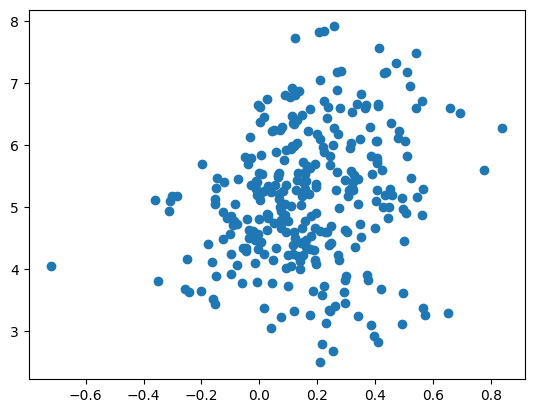

In [9]:
import matplotlib.pyplot as plt
plt.scatter(ref_energy-ref,pred_energy-ref)

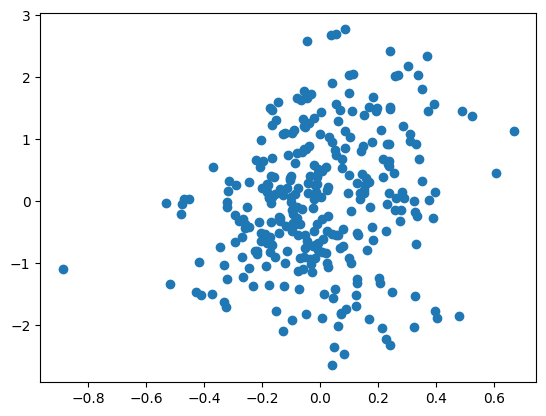

In [10]:
ref_mean = np.mean(ref_energy)
pred_mean = np.mean(pred_energy)
plt.scatter(ref_energy - ref_mean,pred_energy-pred_mean)
ref_energy -= ref_mean
pred_energy -= pred_mean

In [11]:
mae = np.sum(np.abs(ref_energy-pred_energy))/len(ref_energy)

In [12]:
ENERGY(mae,"ev").convert_to("kcal")

np.float64(19.559123344330384)